## ANALYZE A/B TEST DATA

#### PURPOSE:

This script analyzes the A/B test data and answers:

"Does showing anchor pricing 99 USD now 79 USD increase sales?"

WHAT IT DOES:

1. Loads the data from the CSV file
2. Calculates key metrics (conversion rate, revenue, etc.)
3. Runs statistical tests (is the result real or just luck?)
4. Makes a business recommendation
5. Creates visualizations

In [1]:
# Import libraries

import pandas as pd              # For working with data tables
import numpy as np              # For math calculations
import matplotlib.pyplot as plt # For creating charts
import seaborn as sns           # For prettier charts
from scipy import stats         # For statistical tests

print("="*70)
print("A/B TEST ANALYSIS: ANCHOR PRICING EXPERIMENT")
print("="*70)
print("\nCompany: TechGear Electronics")
print("Product: Wireless Headphones")
print("Question: Does '$99 now $79' increase sales vs just '$79'?")
print("\n" + "="*70)

A/B TEST ANALYSIS: ANCHOR PRICING EXPERIMENT

Company: TechGear Electronics
Product: Wireless Headphones
Question: Does '$99 now $79' increase sales vs just '$79'?



In [2]:
# Load and read data
df = pd.read_csv('techgear_ab_test_data.csv')

# Show first few rows to see what the data looks like
df.head()

,visitor_id,test_group,variant,price_shown,visit_date,converted,quantity,traffic_source,device,time_on_page,visitor_type
0,1,A_Control,Just_Price,$79,2025-01-07,0,0,organic_search,desktop,35.834645,returning
1,2,A_Control,Just_Price,$79,2025-01-04,0,0,paid_ads,desktop,58.734647,new
2,3,A_Control,Just_Price,$79,2025-01-02,0,0,direct,mobile,59.760250,returning
3,4,A_Control,Just_Price,$79,2025-01-05,0,0,organic_search,desktop,47.410126,new
4,5,A_Control,Just_Price,$79,2025-01-14,0,0,organic_search,mobile,5.000000,new


In [3]:
# Check column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   visitor_id      20000 non-null  int64  
 1   test_group      20000 non-null  object 
 2   variant         20000 non-null  object 
 3   price_shown     20000 non-null  object 
 4   visit_date      20000 non-null  object 
 5   converted       20000 non-null  int64  
 6   quantity        20000 non-null  int64  
 7   traffic_source  20000 non-null  object 
 8   device          20000 non-null  object 
 9   time_on_page    20000 non-null  float64
 10  visitor_type    20000 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 1.7+ MB


In [4]:
# Convert visit_date from text to actual date format
df['visit_date'] = pd.to_datetime(df['visit_date'])

# Show what we loaded
print(f"✓ Loaded {len(df):,} visitor records")
print(f"✓ Test period: {df['visit_date'].min().date()} to {df['visit_date'].max().date()}")

✓ Loaded 20,000 visitor records
✓ Test period: 2025-01-01 to 2025-01-14


In [5]:
# Split data into two groups

# Filter data to get only Control group (Group A)
control_data = df[df['test_group'] == 'A_Control']

# Filter data to get only Treatment group (Group B)
treatment_data = df[df['test_group'] == 'B_Treatment']

print(f"\nControl Group (A): {len(control_data):,} visitors")
print(f"Treatment Group (B): {len(treatment_data):,} visitors")


Control Group (A): 10,000 visitors
Treatment Group (B): 10,000 visitors


In [6]:
#Calculate key metrics for control group

# How many visitors in control group?
control_visitors = len(control_data)

# How many people bought? (converted = 1)
control_conversions = control_data['converted'].sum()

# Conversion Rate = (People who bought / Total visitors) × 100%
control_conv_rate = control_conversions / control_visitors

# Calculate Total Revenue = Quantity × Price
# Product price is $79
PRODUCT_PRICE = 79

# Create a copy and calculate revenue
control_data = control_data.copy()
control_data['revenue'] = control_data['quantity'] * PRODUCT_PRICE

# Total Revenue = Sum of all revenue
control_revenue = control_data['revenue'].sum()

# Revenue Per Visitor = Total Revenue / Total Visitors
control_rpv = control_revenue / control_visitors

# Print the results
print(f"\nControl Group Results (Show '$79'):")
print(f"  Visitors: {control_visitors:,}")
print(f"  Conversions: {control_conversions}")
print(f"  Conversion Rate: {control_conv_rate*100:.2f}%")
print(f"  Total Revenue: ${control_revenue:,.2f}")
print(f"  Revenue Per Visitor: ${control_rpv:.2f}")


Control Group Results (Show '$79'):
  Visitors: 10,000
  Conversions: 264
  Conversion Rate: 2.64%
  Total Revenue: $25,438.00
  Revenue Per Visitor: $2.54


In [7]:
# Calculate key metrics for treatment group

# Same calculations as control group
treatment_visitors = len(treatment_data)
treatment_conversions = treatment_data['converted'].sum()
treatment_conv_rate = treatment_conversions / treatment_visitors

# Calculate revenue = quantity × price
treatment_data = treatment_data.copy()
treatment_data['revenue'] = treatment_data['quantity'] * PRODUCT_PRICE
treatment_revenue = treatment_data['revenue'].sum()
treatment_rpv = treatment_revenue / treatment_visitors

print(f"\nTreatment Group Results (Show '~~$99~~ $79'):")
print(f"  Visitors: {treatment_visitors:,}")
print(f"  Conversions: {treatment_conversions}")
print(f"  Conversion Rate: {treatment_conv_rate*100:.2f}%")
print(f"  Total Revenue: ${treatment_revenue:,.2f}")
print(f"  Revenue Per Visitor: ${treatment_rpv:.2f}")


Treatment Group Results (Show '~~$99~~ $79'):
  Visitors: 10,000
  Conversions: 346
  Conversion Rate: 3.46%
  Total Revenue: $35,076.00
  Revenue Per Visitor: $3.51


In [8]:
# Calculate lift (How Much Better Is Treatment?)

# Lift = ((Treatment - Control) / Control) × 100%
# This tells us: "Treatment is X% better than Control"

# Conversion Rate Lift
conv_lift = ((treatment_conv_rate - control_conv_rate) / control_conv_rate) * 100

# Revenue Per Visitor Lift
rpv_lift = ((treatment_rpv - control_rpv) / control_rpv) * 100

print(f"\nLift (How much better is Treatment?):")
print(f"  Conversion Rate: {conv_lift:.1f}%")
print(f"  Revenue Per Visitor: {rpv_lift:.1f}%")


Lift (How much better is Treatment?):
  Conversion Rate: 31.1%
  Revenue Per Visitor: 37.9%


In [9]:
# Statistical Test (Is this real or just luck?)

# Create a contingency table to show how many converted vs didn't convert in each group
contingency_table = pd.crosstab(df['test_group'], df['converted'])

print("\nContingency Table:")
print(contingency_table)


Contingency Table:
converted       0    1
test_group            
A_Control    9736  264
B_Treatment  9654  346


In [10]:
# Run Chi-Square Test
# This test compares two groups and returns a p-value
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Test Results:")
print(f"  P-value: {p_value:.4f}")


Chi-Square Test Results:
  P-value: 0.0009


In [11]:
# Interpret the p-value
# It means P-value = Probability this is just random luck

if p_value < 0.01:
    print(f"  HIGHLY SIGNIFICANT (p < 0.01)")
    print(f"  Less than 1% chance this is luck.")
    print(f"  The difference is REAL!")
elif p_value < 0.05:
    print(f"  SIGNIFICANT (p < 0.05)")
    print(f"  Less than 5% chance this is luck.")
    print(f"  The difference is statistically significant.")
else:
    print(f"  NOT SIGNIFICANT (p >= 0.05)")
    print(f"  More than 5% chance this is just luck.")
    print(f"  We CANNOT trust this result!")

  HIGHLY SIGNIFICANT (p < 0.01)
  Less than 1% chance this is luck.
  The difference is REAL!


In [12]:
# Business Recommendation

# Make decision based on statistical test and lift
if p_value < 0.05 and conv_lift > 0:
    print(f"\n✓ RECOMMENDATION: IMPLEMENT TREATMENT (B)")
    print(f"\nWHY?")
    print(f"  - Conversion rate increased by {conv_lift:.1f}%")
    print(f"  - This is statistically significant (p = {p_value:.4f})")
    print(f"  - We can be {(1-p_value)*100:.1f}% confident this is real")

    # Project what this means for revenue
    print(f"\nPROJECTED ANNUAL IMPACT:")

    # Assumptions
    monthly_visitors = 100000  # Example: 100K visitors per month
    avg_order_value = 85       # Average order value

    # Calculate additional conversions
    current_monthly_conversions = monthly_visitors * control_conv_rate
    new_monthly_conversions = monthly_visitors * treatment_conv_rate
    additional_conversions = new_monthly_conversions - current_monthly_conversions

    # Calculate revenue impact
    monthly_revenue_increase = additional_conversions * avg_order_value
    annual_revenue_increase = monthly_revenue_increase * 12

    print(f"  Assuming {monthly_visitors:,} monthly visitors")
    print(f"  Additional monthly conversions: {additional_conversions:,.0f}")
    print(f"  Monthly revenue increase: ${monthly_revenue_increase:,.0f}")
    print(f"  Annual revenue increase: ${annual_revenue_increase:,.0f}")
    print(f"  Implementation cost: $0")

else:
    print(f"\n✗ RECOMMENDATION: DO NOT IMPLEMENT")
    print(f"\nWHY?")
    print(f"  The result is not statistically significant (p = {p_value:.4f})")
    print(f"  There's a {p_value*100:.1f}% chance this is just random luck")
    print(f"  We should run the test longer or with more traffic")


✓ RECOMMENDATION: IMPLEMENT TREATMENT (B)

WHY?
  - Conversion rate increased by 31.1%
  - This is statistically significant (p = 0.0009)
  - We can be 99.9% confident this is real

PROJECTED ANNUAL IMPACT:
  Assuming 100,000 monthly visitors
  Additional monthly conversions: 820
  Monthly revenue increase: $69,700
  Annual revenue increase: $836,400
  Implementation cost: $0


In [13]:
# Create visualizations
# Set up colors
navy = '#0A2463'
teal = '#14B8A6'

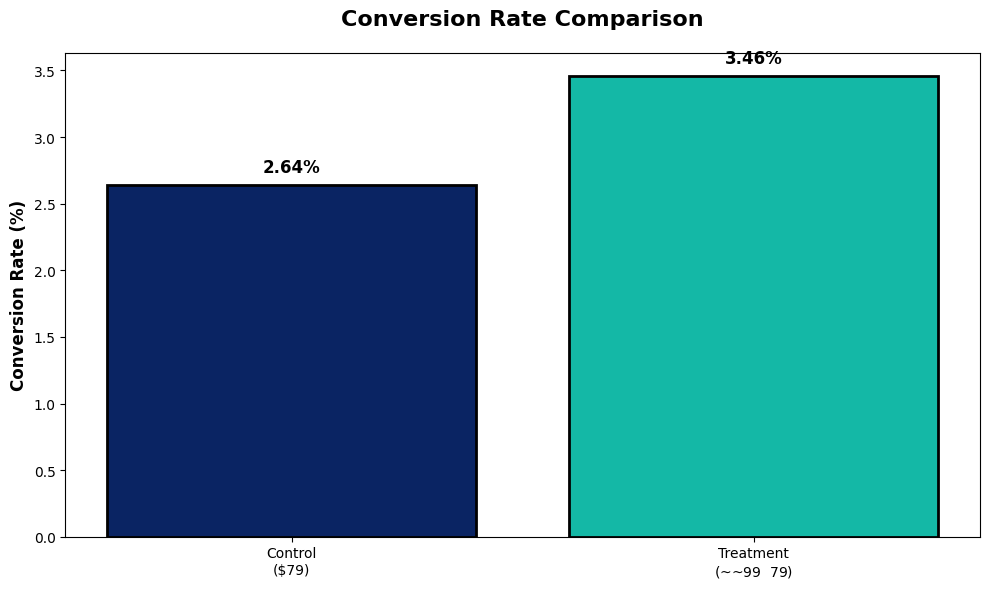

In [14]:
# CHART 1: Conversion rate comparison

# Create a new figure (blank canvas)
plt.figure(figsize=(10, 6))

# Data for the chart
groups = ['Control\n($79)', 'Treatment\n(~~$99~~ $79)']
conv_rates = [control_conv_rate * 100, treatment_conv_rate * 100]

# Create bar chart
plt.bar(groups, conv_rates, color=[navy, teal], edgecolor='black', linewidth=2)

# Add labels
plt.ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
plt.title('Conversion Rate Comparison', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, val in enumerate(conv_rates):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)

# Save this chart
plt.tight_layout()
plt.savefig('chart1_conversion_rate.png', dpi=300, bbox_inches='tight');


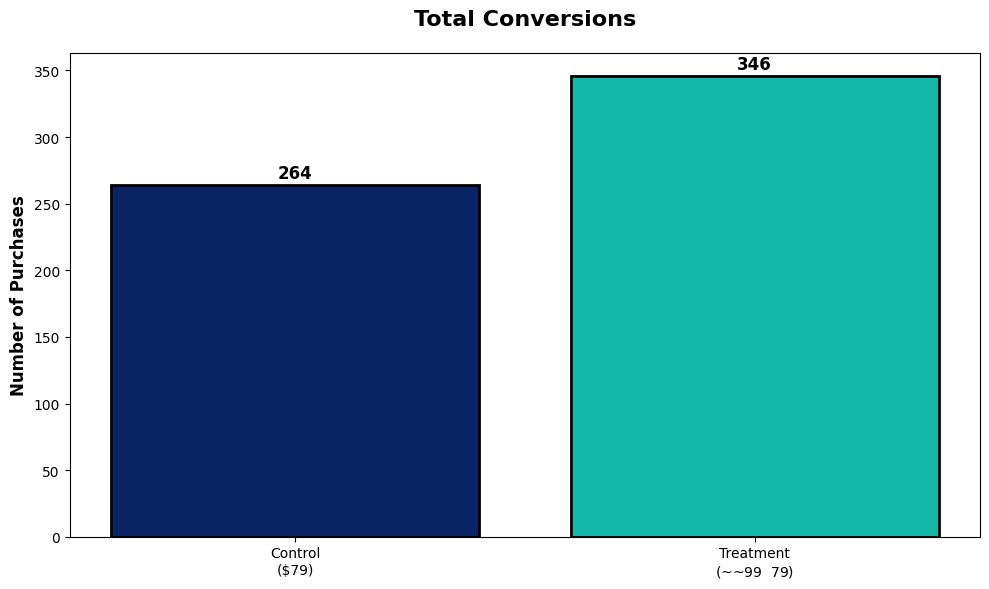

In [15]:
# CHART 2: Total conversions

plt.figure(figsize=(10, 6))

conversions = [control_conversions, treatment_conversions]

plt.bar(groups, conversions, color=[navy, teal], edgecolor='black', linewidth=2)
plt.ylabel('Number of Purchases', fontsize=12, fontweight='bold')
plt.title('Total Conversions', fontsize=16, fontweight='bold', pad=20)

for i, val in enumerate(conversions):
    plt.text(i, val + 5, f'{int(val):,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('chart2_conversions.png', dpi=300, bbox_inches='tight');

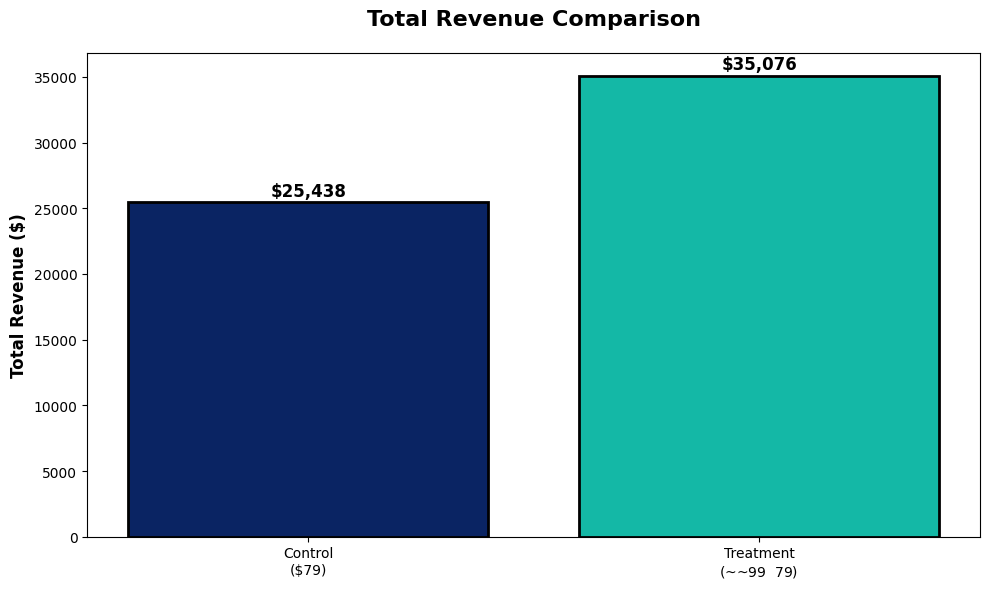

In [16]:
# CHART 3: Revenue per visitor

plt.figure(figsize=(10, 6))

total_revenues = [control_revenue, treatment_revenue]

plt.bar(groups, total_revenues, color=[navy, teal], edgecolor='black', linewidth=2)
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Total Revenue Comparison', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, val in enumerate(total_revenues):
    plt.text(i, val + 500, f'${val:,.0f}', ha='center', fontweight='bold', fontsize=12)

# Calculate revenue difference
revenue_difference = treatment_revenue - control_revenue
revenue_lift_pct = ((treatment_revenue - control_revenue) / control_revenue) * 100

plt.tight_layout()
plt.savefig('chart3_total_revenue.png', dpi=300, bbox_inches='tight');

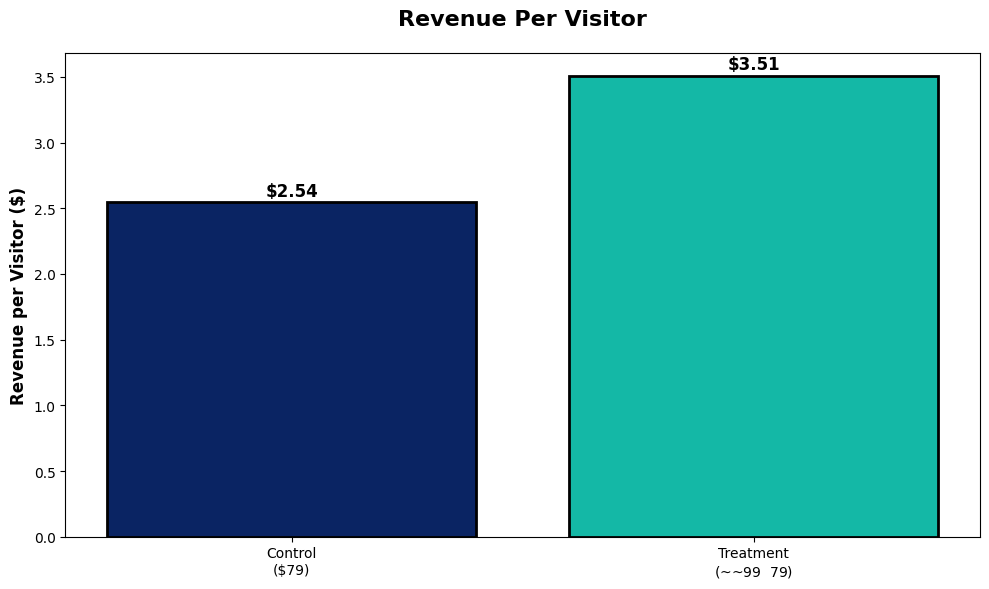

In [17]:
# CHART 4: Revenue Per Visitor

plt.figure(figsize=(10, 6))

rpv_values = [control_rpv, treatment_rpv]

plt.bar(groups, rpv_values, color=[navy, teal], edgecolor='black', linewidth=2)
plt.ylabel('Revenue per Visitor ($)', fontsize=12, fontweight='bold')
plt.title('Revenue Per Visitor', fontsize=16, fontweight='bold', pad=20)

for i, val in enumerate(rpv_values):
    plt.text(i, val + 0.05, f'${val:.2f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('chart4_revenue_per_visitor.png', dpi=300, bbox_inches='tight');

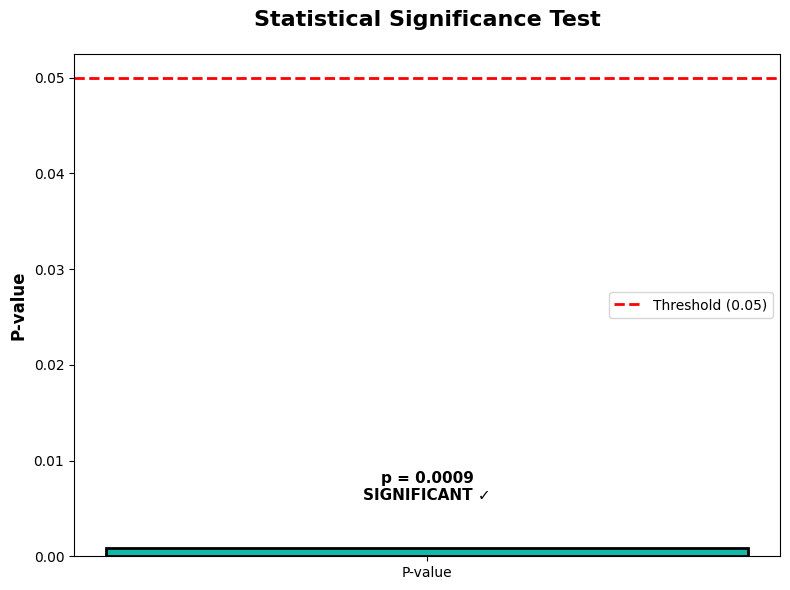

In [18]:
# CHART 4: Statistical significance

plt.figure(figsize=(8, 6))

# Color: Green if significant, Red if not
bar_color = teal if p_value < 0.05 else '#E74C3C'

plt.bar(['P-value'], [p_value], color=bar_color, edgecolor='black', linewidth=2)

# Add red line showing the threshold
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Threshold (0.05)')

plt.ylabel('P-value', fontsize=12, fontweight='bold')
plt.title('Statistical Significance Test', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=10)

# Add text showing if significant or not
sig_text = 'SIGNIFICANT ✓' if p_value < 0.05 else 'NOT SIGNIFICANT ✗'
plt.text(0, p_value + 0.005, f'p = {p_value:.4f}\n{sig_text}',
         ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('chart5_significance.png', dpi=300, bbox_inches='tight');